# Notebook 1: Financial Analysis Engine
## Turkish Banks Credit Risk & Rating Analysis Platform

**Analyst:** Ali Kızıltoprak  
**Phase:** 1 of 3  
**Objective:** Load financial data, calculate CAMELS-inspired metrics, score and rank 6 major Turkish banks

---

## 1. Setup & Imports

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import FinancialDataLoader, BANKS, FITCH_RATINGS
from src.financial_metrics import FinancialMetricsEngine

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)
print('Setup complete.')

Setup complete.


## 2. Load Financial Data

In [2]:
loader = FinancialDataLoader()
df = loader.load_sample_financials()

print(f'Banks loaded: {len(df)}')
print(f'Metrics available: {len(df.columns)}')
df.head()

Banks loaded: 6
Metrics available: 17


,name,ownership,car_pct,cet1_pct,leverage_ratio,npl_ratio,coverage_ratio,cost_of_risk,roe_pct,roa_pct,nim_pct,cost_income,loan_deposit,lcr_pct,fx_loan_share,fx_funding_gap,total_assets_bn_try
bank,,,,,,,,,,,,,,,,,
GARAN,Garanti BBVA,Private,17.20,14.10,8.20,2.10,85.00,1.20,38.50,3.80,5.20,28.50,88.50,185.00,28.50,2.10,1850
AKBNK,Akbank,Private,18.50,15.20,9.10,1.80,88.00,1.00,35.20,3.50,4.80,30.20,85.20,192.00,25.20,1.80,1650
ISCTR,İş Bankası,Private,16.80,13.90,7.80,3.20,75.00,1.80,32.10,2.90,4.50,35.80,92.10,175.00,32.10,3.50,1920
YKBNK,Yapı Kredi,Private,15.90,12.80,7.20,4.50,70.00,2.10,28.90,2.40,4.20,38.10,98.50,162.00,35.80,4.20,1420
HALKB,Halkbank,State,14.20,11.50,6.50,5.80,60.00,2.80,22.50,1.80,3.80,42.50,102.30,145.00,38.20,5.80,980


## 3. Capital Adequacy Analysis

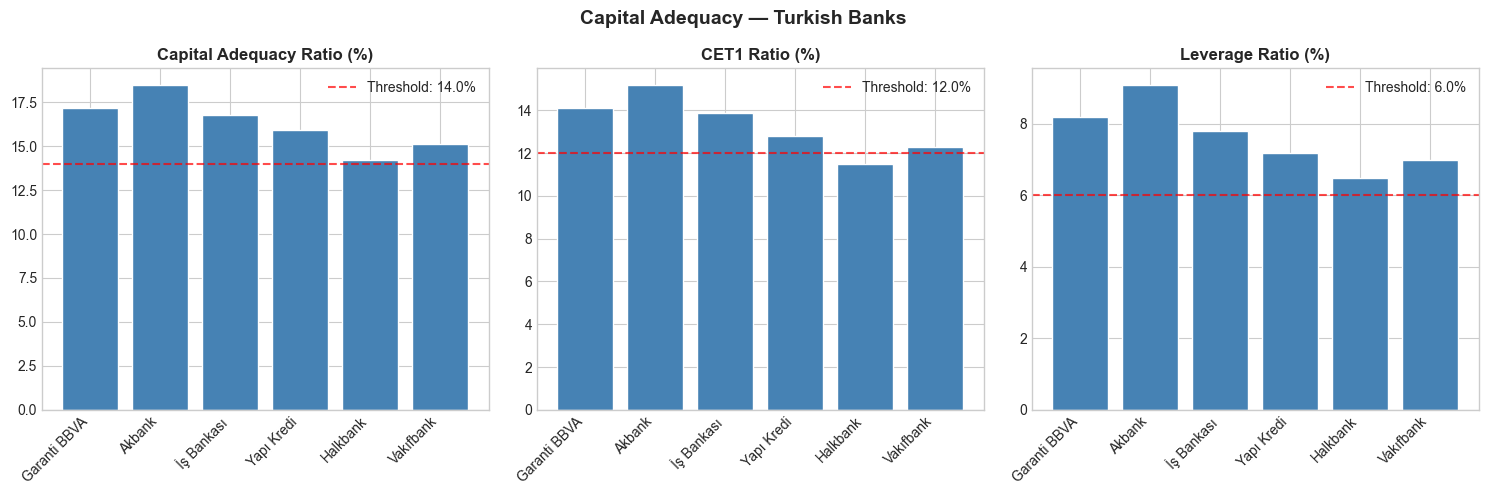

In [3]:
# Capital metrics
capital_cols = ['name', 'car_pct', 'cet1_pct', 'leverage_ratio']
capital_df = df[capital_cols].sort_values('cet1_pct', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title, threshold in zip(
    axes,
    ['car_pct', 'cet1_pct', 'leverage_ratio'],
    ['Capital Adequacy Ratio (%)', 'CET1 Ratio (%)', 'Leverage Ratio (%)'],
    [14.0, 12.0, 6.0]
):
    bars = ax.bar(df['name'], df[col], color='steelblue', edgecolor='white')
    ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, label=f'Threshold: {threshold}%')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(df['name'], rotation=45, ha='right')
    ax.legend()

plt.suptitle('Capital Adequacy — Turkish Banks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/capital_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Asset Quality Analysis

In [4]:
# TODO: Plot NPL ratio, coverage ratio, cost of risk
# Similar structure to capital analysis above
pass

## 5. Profitability Analysis

In [5]:
# TODO: ROE, ROA, NIM, Cost-to-Income
pass

## 6. Composite Scoring & Rating Comparison

In [6]:
engine = FinancialMetricsEngine(df)
scores = engine.calculate_pillar_scores()

print('=== Pillar Scores ===')
display(scores[['name', 'capital', 'asset_quality', 'profitability', 
                'liquidity', 'fx_sensitivity', 'composite_score']])

print('\n=== Model vs Fitch Ratings ===')
comparison = engine.generate_rating_comparison()
display(comparison[['name', 'composite_score', 'model_implied_rating', 'fitch_lt_idr']])

=== Pillar Scores ===


,name,capital,asset_quality,profitability,liquidity,fx_sensitivity,composite_score
bank,,,,,,,
GARAN,Garanti BBVA,75.00,95.80,100.00,94.20,85.80,89.70
AKBNK,Akbank,83.30,100.00,97.50,99.70,91.30,94.00
ISCTR,İş Bankası,72.20,65.60,86.40,85.70,79.80,76.50
YKBNK,Yapı Kredi,62.40,46.90,78.00,68.50,73.90,64.30
HALKB,Halkbank,49.20,26.00,57.00,54.40,70.70,49.00
VAKBN,Vakıfbank,56.20,53.10,71.90,71.00,73.00,63.30



=== Model vs Fitch Ratings ===


,name,composite_score,model_implied_rating,fitch_lt_idr
bank,,,,
GARAN,Garanti BBVA,89.70,BB+,B
AKBNK,Akbank,94.00,BB+,B
ISCTR,İş Bankası,76.50,BB,B
YKBNK,Yapı Kredi,64.30,B+,B
HALKB,Halkbank,49.00,B,B-
VAKBN,Vakıfbank,63.30,B+,B


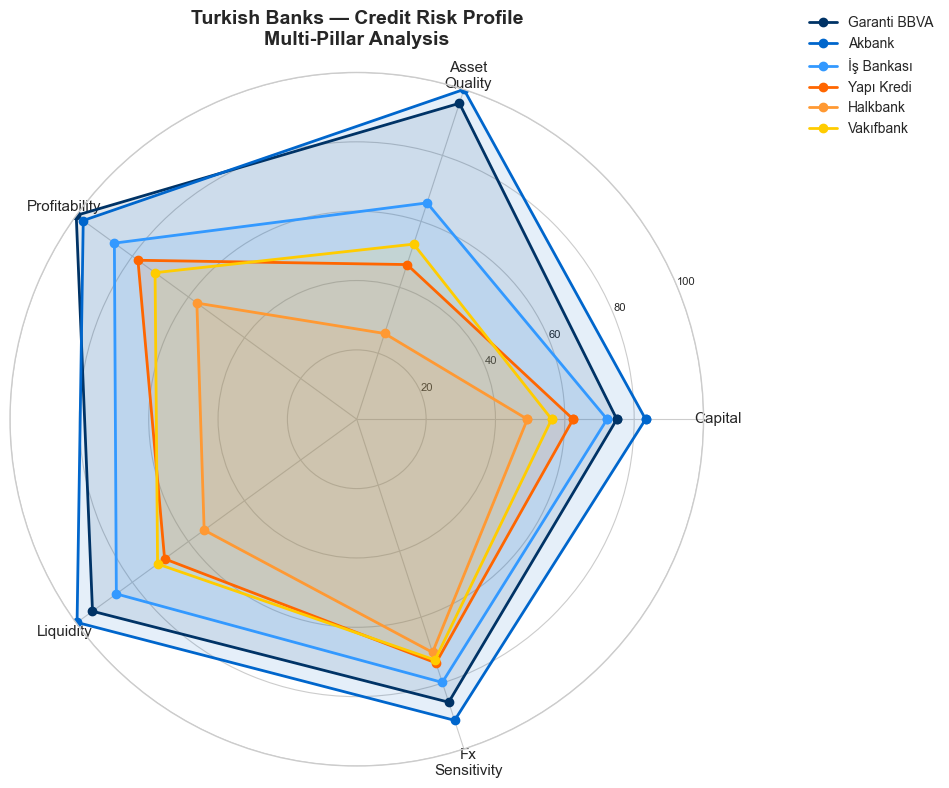

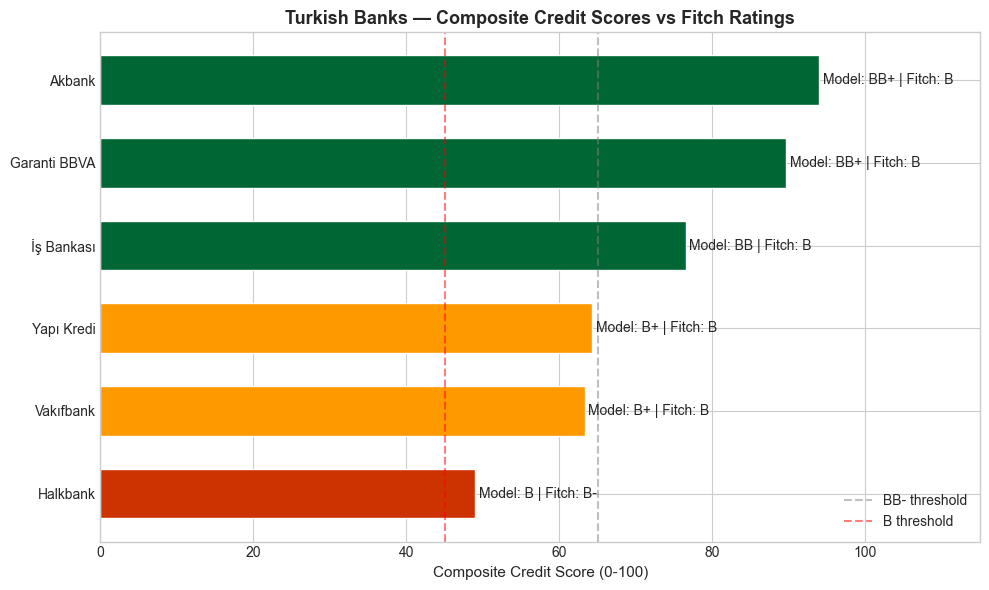

In [7]:
# Radar chart
fig = engine.plot_radar_chart(save_path='../reports/radar_chart.png')
plt.show()

# Composite scores bar chart
fig2 = engine.plot_composite_scores(save_path='../reports/composite_scores.png')
plt.show()

## 7. Key Findings

**Top-tier (B+ implied):** Akbank, Garanti BBVA  
**Mid-tier (B implied):** İş Bankası  
**Below-tier (B- implied):** Yapı Kredi, Vakıfbank, Halkbank  

**State bank discount:** State-owned banks (Halkbank, Vakıfbank) show weaker standalone metrics — consistent with Fitch's FI methodology which distinguishes VR from sovereign support floors.

**Next:** Notebook 02 — Sovereign Risk Linkage